In [32]:
# Installation (si nécessaire, à exécuter une seule fois)
!pip install seaborn matplotlib pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Importation du dataset
df = pd.read_csv("../data/mesures_capteurs.csv")

In [35]:
# Apercu des premières lignes du dataset
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [36]:
# Dimensions du dataset
print(df.shape)

(605, 9)


In [37]:
# Informations générales (types, valeurs manquantes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [38]:
# Statistiques descriptives
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [39]:
# Vérification des valeurs manquantes
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

# Partie 1 - Distribution d'une variable avec histplot() 
1) Afficher la distributions des temperatures

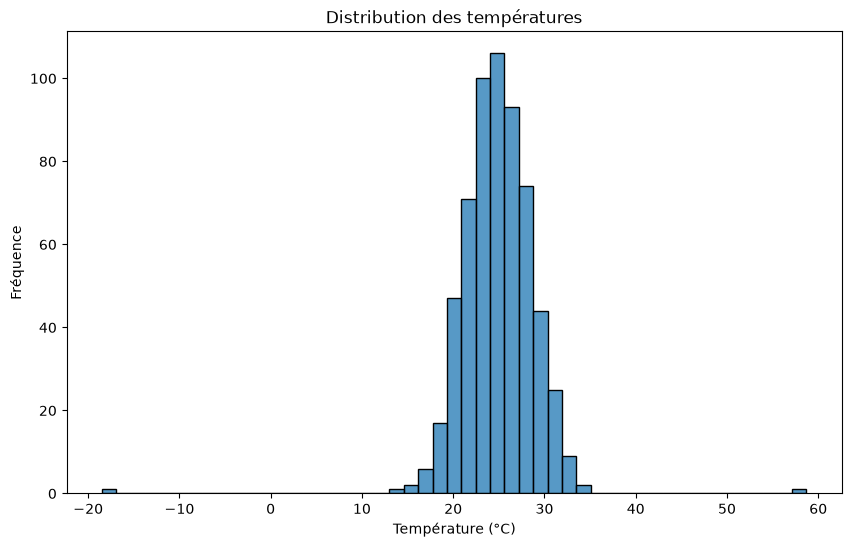

In [45]:
# Affichage des graphiques directement dans le notebook

%matplotlib inline


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

2) Autour de quelle valeur les températures sont concentrées ? 

Les temperatures sont concentrees entre 20°C et 30°C avec un pic autour de 24-25°

3) La distribution semble-t-elle symétrique ? 

La distribution semble globalement symetrique : elle augmente progressivement jusqu'à un sommet vers 24-25°C, puis redescend de façon similaire.


4) Existe-t-il des valeurs extrêmes ? 
 
 On peut observer des valeurs extremes : environ -18°C et 58°C, ces valeurs sont isolees du reste de la distribution

5) Modifier le nombre de classes 

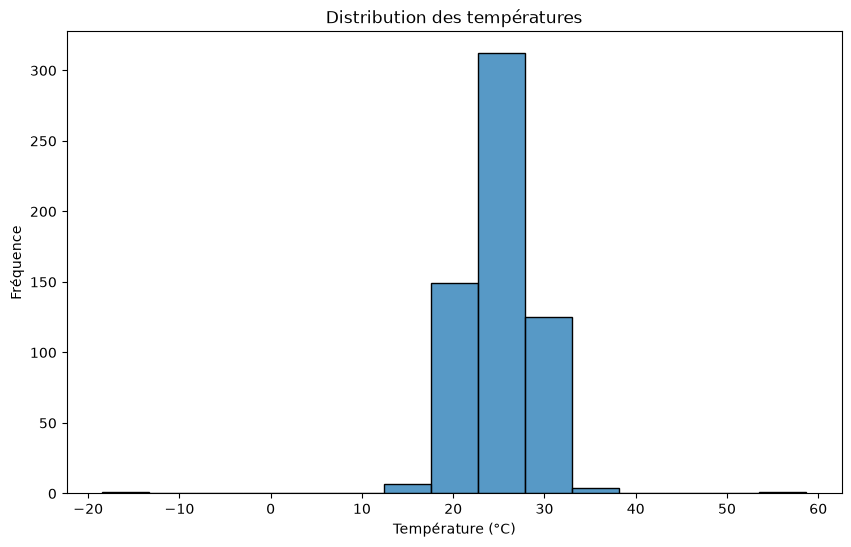

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature", bins=15)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

# bins permet de definir le nombre de classes pour l'histogramme. Plus le nombre de bins est élevé, plus l'histogramme sera détaillé.

6) Afficher la distribution des températures par bâtiment 

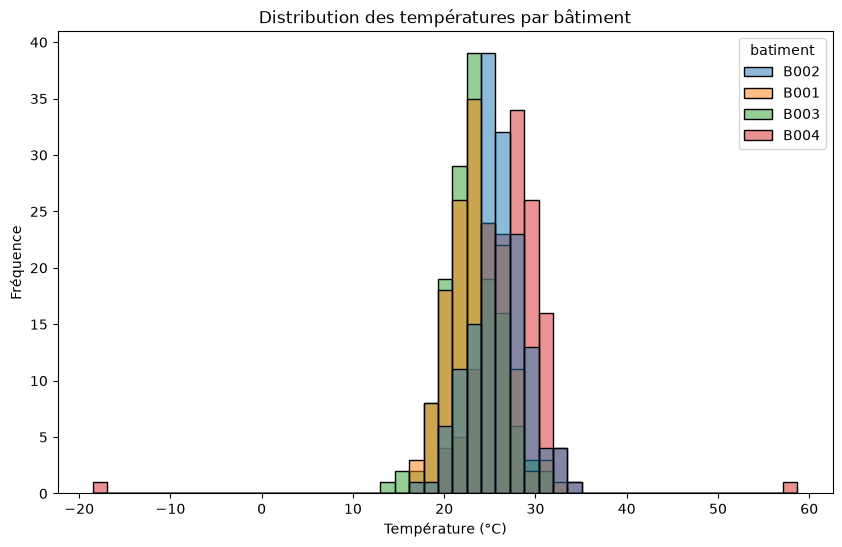

In [47]:
# hue permet de separer et colorer l'histogramme selon une variable categorielle,

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature", hue="batiment")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()


Les températures sont globalement homogènes entre bâtiments, avec une variation modérée du pic selon le bâtiment, et une anomalie isolée sur B004.

# Partie 2 - Distribution d'une variable avec kdeplot() 

1) Afficher la distribution des températures 

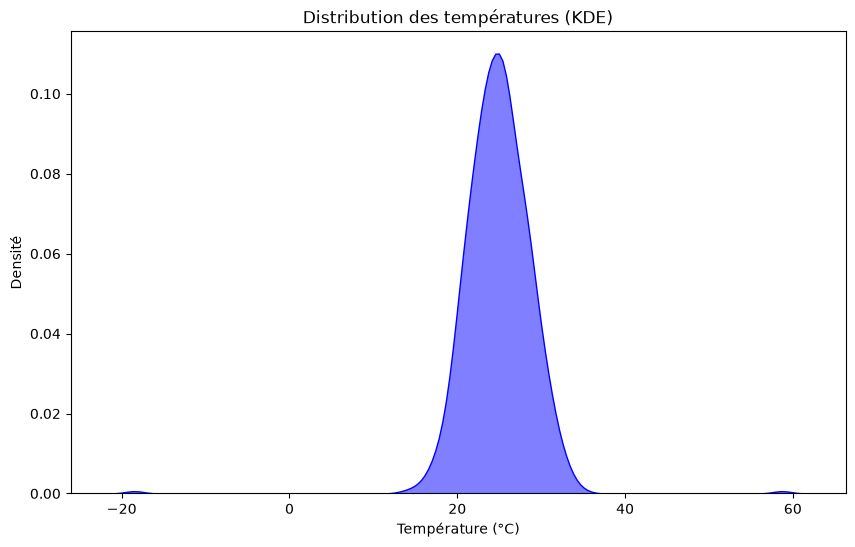

In [ ]:
# kdeplot affiche une estimation de densite (courbe lissee) de la distribution,
# plus lisible qu'un histogramme pour voir la forme generale de la repartition.
# fill=True permet de remplir la zone sous la courbe, alpha=0.5 ajuste la transparence, color="blue" change la couleur de la courbe.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature",fill=True, alpha=0.5, color="blue")
plt.title("Distribution des températures (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

2) Afficher la distribution des températures par bâtiment 

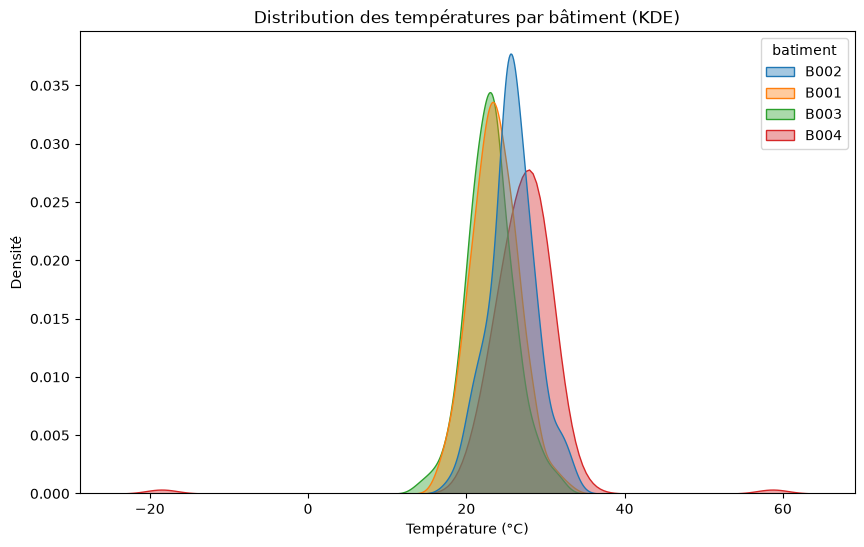

In [55]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.4)
plt.title("Distribution des températures par bâtiment (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

**Observations (KDE par bâtiment) :**

- Chaque bâtiment a une température moyenne différente : B003 et B001 sont plutôt
  frais (~22-23°C), B002 est moyen (~24-25°C), et B004 est le plus chaud (~27-28°C).
- B002 a des températures très stables (courbe haute et fine).
  B004 a des températures plus variables (courbe basse et étalée).
- B004 est aussi le seul bâtiment avec des valeurs extrêmes (proches de -20°C et 60°C).

# Partie 3 – Distribution d'une variable avec boxplot() 

1) Afficher la distribution des températures 

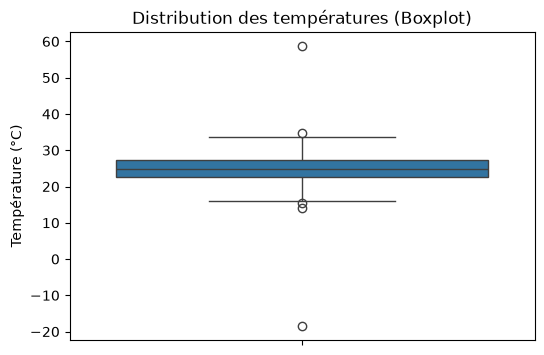

In [61]:
# boxplot affiche la mediane, les quartiles et les valeurs extremes (outliers)
# sous forme de boite a moustaches.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y="temperature")
plt.title("Distribution des températures (Boxplot)")
plt.ylabel("Température (°C)")
plt.show()

2) Afficher la distribution des températures par bâtiment 

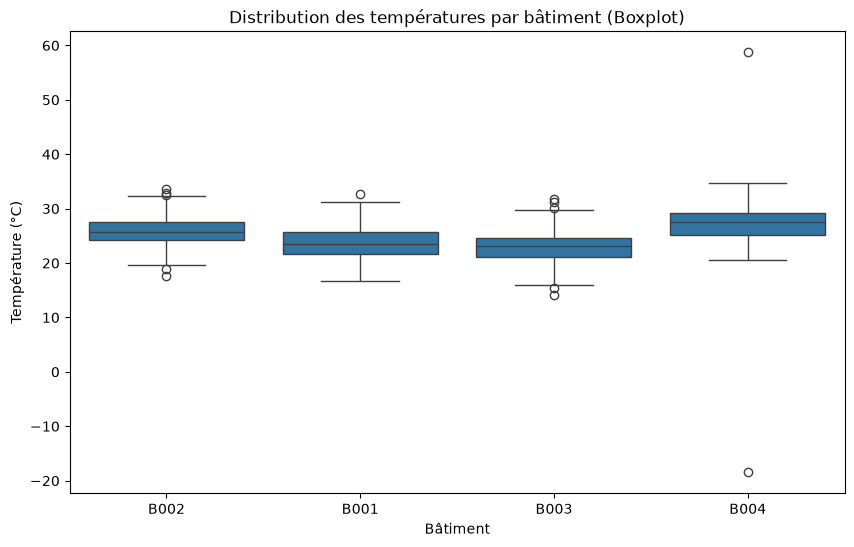

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Distribution des températures par bâtiment (Boxplot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()